<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/00_AED_exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB00 — Análise Exploratória Inicial do Dataset Original

## 1. Contexto

Este notebook realiza a análise exploratória inicial do dataset original utilizado no projeto.

Diferentemente dos notebooks posteriores do pipeline, esta etapa parte exclusivamente do arquivo bruto disponibilizado a partir do Kaggle:

`Mestrado/02-datasets/01-raw/borg_traces_data.csv`

O objetivo é caracterizar a estrutura empírica inicial do conjunto de dados antes da construção dos artefatos derivados, como séries temporais agregadas, episódios críticos, atributos temporais, estados operacionais e bases supervisionadas.

Dessa forma, o NB00 passa a cumprir o papel de uma AED prévia, independente e reprodutível, evitando dependência de artefatos produzidos por notebooks posteriores.

## 2. Objetivo

Os objetivos deste notebook são:

- carregar o dataset original do Kaggle;
- validar sua estrutura básica;
- caracterizar o volume de registros e colunas disponíveis;
- analisar a distribuição dos tipos de evento;
- analisar a distribuição da variável de falha;
- examinar atributos operacionais relevantes, como `scheduling_class` e `priority`;
- avaliar a cobertura temporal do dataset;
- investigar o comportamento inicial da série, especialmente a primeira hora;
- construir uma agregação exploratória em janelas de 5 minutos, calculada dentro do próprio NB00;
- analisar, de forma descritiva, volume de eventos, falhas e taxa de falha ao longo do tempo;
- gerar figuras e tabelas exploratórias;
- salvar um resumo estruturado da AED.

## 3. Papel no Pipeline Atualizado

O NB00 tem papel exclusivamente exploratório.

Ele não executa a detecção oficial de episódios críticos, não constrói atributos finais, não rotula estados operacionais e não treina modelos supervisionados.

Sua função é anteceder e motivar as decisões metodológicas dos notebooks posteriores, especialmente:

- a necessidade de normalização temporal;
- a adoção de janelas temporais fixas;
- o uso da taxa de falha como variável analítica;
- a atenção ao comportamento do bloco inicial da série;
- a existência de heterogeneidade operacional no dataset.

## 4. Entrada Única

A entrada única deste notebook é:

`/content/drive/MyDrive/Mestrado/02-datasets/01-raw/borg_traces_data.csv`

Este notebook não lê artefatos produzidos por NB03, NB04, NB05, NB06, NB07, NB08 ou NB09.

Em particular, não são utilizados como entrada:

- `window_5min_series.parquet`;
- `window_5min_series_scored.parquet`;
- `episodes_detected.parquet`;
- `window_5min_features.parquet`;
- `window_5min_labeled.parquet`;
- `anticipation_supervised_dataset.parquet`;
- `transition_dataset.parquet`;
- summaries de notebooks posteriores.

## 5. Saídas Geradas

As saídas deste notebook são artefatos próprios da AED:

- `00_aed_summary.json`;
- `00_aed_exploratory_5min_series.parquet`;
- figuras exploratórias em `04-reports/figures_nb00_aed/`.

O arquivo `00_aed_exploratory_5min_series.parquet` é apenas um cache exploratório gerado pelo próprio NB00. Ele não substitui a série oficial produzida posteriormente no pipeline.

## 6. Eixos da Análise

A AED está organizada nos seguintes eixos:

1. validação estrutural do dataset bruto;
2. distribuição dos tipos de evento;
3. distribuição da variável de falha;
4. análise de variáveis operacionais básicas;
5. cobertura temporal e comportamento por hora;
6. análise específica da primeira hora da série;
7. agregação exploratória em janelas de 5 minutos;
8. comportamento exploratório de eventos, falhas e taxa de falha;
9. síntese dos achados relevantes para as próximas etapas.

## 7. Observações Metodológicas

Esta etapa tem caráter descritivo e exploratório.

As estatísticas e figuras geradas aqui não substituem os procedimentos oficiais de processamento, detecção de episódios, engenharia de atributos, rotulagem e modelagem supervisionada.

A agregação em janelas de 5 minutos feita neste notebook é exploratória e calculada localmente, com o objetivo de compreender a estrutura temporal inicial do dataset.

As decisões oficiais do pipeline permanecem documentadas nos notebooks posteriores.

In [2]:
# ============================================================
# NB00 — Célula 1
# Bootstrap + geração de cache técnico próprio a partir do CSV bruto Kaggle
# ============================================================

from pathlib import Path
import subprocess
import sys
import os
import pandas as pd

# -----------------------------
# 0) Monta Google Drive, se necessário
# -----------------------------
if not Path("/content/drive/MyDrive").exists():
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("[Bootstrap] Google Drive já montado.")

# -----------------------------
# 1) Instala/importa DuckDB
# -----------------------------
try:
    import duckdb
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb"], check=True)
    import duckdb

# -----------------------------
# 2) Caminhos principais
# -----------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
MESTRADO_ROOT = DRIVE_ROOT / "Mestrado"

REPORTS_PATH = MESTRADO_ROOT / "04-reports"
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

AED_CACHE_FILE = REPORTS_PATH / "00_aed_source_cache.parquet"

# Caminho esperado
RAW_FILE_EXPECTED = MESTRADO_ROOT / "02-datasets" / "01-raw" / "borg_traces_data.csv"

# Procura alternativas, se o caminho esperado não existir
if RAW_FILE_EXPECTED.exists():
    RAW_FILE = RAW_FILE_EXPECTED
else:
    print("[Bootstrap] Arquivo não encontrado no caminho esperado:")
    print(RAW_FILE_EXPECTED)
    print("\n[Bootstrap] Procurando borg_traces_data.csv dentro de MyDrive/Mestrado...")

    matches = list(MESTRADO_ROOT.rglob("borg_traces_data.csv")) if MESTRADO_ROOT.exists() else []

    if not matches:
        print("\n[Bootstrap] Não encontrado em MyDrive/Mestrado. Procurando em MyDrive...")
        matches = list(DRIVE_ROOT.rglob("borg_traces_data.csv"))

    if not matches:
        raise FileNotFoundError(
            "Arquivo borg_traces_data.csv não encontrado no Google Drive. "
            "Confirme se ele está em MyDrive/Mestrado/02-datasets/01-raw/."
        )

    RAW_FILE = matches[0]
    print("\n[Bootstrap] Arquivo encontrado em:")
    print(RAW_FILE)

FORCE_REBUILD_CACHE = True

print("\nRAW_FILE =", RAW_FILE)
print("AED_CACHE_FILE =", AED_CACHE_FILE)

# -----------------------------
# 3) Inspeciona cabeçalho sem carregar o CSV inteiro
# -----------------------------
raw_columns = [str(c).strip() for c in pd.read_csv(RAW_FILE, nrows=0).columns]

print("\nColunas encontradas no CSV:")
print(raw_columns)

required_cols = {"time", "event"}
missing_required = required_cols - set(raw_columns)
assert not missing_required, f"Colunas obrigatórias ausentes: {missing_required}"

# -----------------------------
# 4) Define colunas mínimas para a AED
# -----------------------------
desired_optional_cols = [
    "failed",
    "scheduling_class",
    "priority",
]

selected_cols = ["time", "event"] + [c for c in desired_optional_cols if c in raw_columns]

print("\nColunas selecionadas para o cache do NB00:")
print(selected_cols)

def qcol(col: str) -> str:
    return '"' + col.replace('"', '""') + '"'

# -----------------------------
# 5) Monta SELECT robusto
# -----------------------------
select_exprs = [
    f"TRY_CAST({qcol('time')} AS BIGINT) AS time",
    f"CAST({qcol('event')} AS VARCHAR) AS event",
]

if "failed" in raw_columns:
    select_exprs.append(
        f"""
        COALESCE(
            TRY_CAST({qcol('failed')} AS INTEGER),
            CASE WHEN UPPER(CAST({qcol('event')} AS VARCHAR)) = 'FAIL' THEN 1 ELSE 0 END
        ) AS failed
        """
    )
else:
    select_exprs.append(
        f"""
        CASE WHEN UPPER(CAST({qcol('event')} AS VARCHAR)) = 'FAIL' THEN 1 ELSE 0 END AS failed
        """
    )

if "scheduling_class" in raw_columns:
    select_exprs.append(
        f"TRY_CAST({qcol('scheduling_class')} AS INTEGER) AS scheduling_class"
    )

if "priority" in raw_columns:
    select_exprs.append(
        f"TRY_CAST({qcol('priority')} AS DOUBLE) AS priority"
    )

select_sql = ",\n    ".join(select_exprs)

raw_path_sql = str(RAW_FILE).replace("'", "''")
cache_path_sql = str(AED_CACHE_FILE).replace("'", "''")

# -----------------------------
# 6) Gera cache parquet próprio do NB00
# -----------------------------
if AED_CACHE_FILE.exists() and not FORCE_REBUILD_CACHE:
    print("\nCache já existe. Reutilizando:", AED_CACHE_FILE)
else:
    if AED_CACHE_FILE.exists():
        AED_CACHE_FILE.unlink()

    print("\nGerando cache parquet próprio do NB00 com DuckDB...")

    con = duckdb.connect(database=":memory:")

    sql = f"""
    COPY (
        SELECT
            {select_sql}
        FROM read_csv_auto(
            '{raw_path_sql}',
            HEADER = TRUE,
            ALL_VARCHAR = TRUE,
            SAMPLE_SIZE = 20000
        )
        WHERE TRY_CAST({qcol('time')} AS BIGINT) IS NOT NULL
          AND CAST({qcol('event')} AS VARCHAR) IS NOT NULL
    )
    TO '{cache_path_sql}'
    (FORMAT PARQUET, COMPRESSION ZSTD);
    """

    con.execute(sql)
    con.close()

    print("Cache gerado com sucesso:", AED_CACHE_FILE)

# -----------------------------
# 7) Validação rápida do cache
# -----------------------------
con = duckdb.connect(database=":memory:")

info = con.execute(f"""
    SELECT
        COUNT(*) AS rows,
        MIN(time) AS time_min,
        MAX(time) AS time_max
    FROM read_parquet('{cache_path_sql}')
""").df()

sample = con.execute(f"""
    SELECT *
    FROM read_parquet('{cache_path_sql}')
    LIMIT 5
""").df()

con.close()

print("\nResumo do cache:")
display(info)

print("\nAmostra do cache:")
display(sample)

[Bootstrap] Google Drive já montado.

RAW_FILE = /content/drive/MyDrive/Mestrado/02-datasets/01-raw/borg_traces_data.csv
AED_CACHE_FILE = /content/drive/MyDrive/Mestrado/04-reports/00_aed_source_cache.parquet

Colunas encontradas no CSV:
['Unnamed: 0', 'time', 'instance_events_type', 'collection_id', 'scheduling_class', 'collection_type', 'priority', 'alloc_collection_id', 'instance_index', 'machine_id', 'resource_request', 'constraint', 'collections_events_type', 'user', 'collection_name', 'collection_logical_name', 'start_after_collection_ids', 'vertical_scaling', 'scheduler', 'start_time', 'end_time', 'average_usage', 'maximum_usage', 'random_sample_usage', 'assigned_memory', 'page_cache_memory', 'cycles_per_instruction', 'memory_accesses_per_instruction', 'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution', 'cluster', 'event', 'failed']

Colunas selecionadas para o cache do NB00:
['time', 'event', 'failed', 'scheduling_class', 'priority']

Gerando cache parquet p

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Cache gerado com sucesso: /content/drive/MyDrive/Mestrado/04-reports/00_aed_source_cache.parquet

Resumo do cache:


,rows,time_min,time_max
0,405894,0,9223372036854775807



Amostra do cache:


,time,event,failed,scheduling_class,priority
0,0,FAIL,1,3,200.0
1,2517305308183,FAIL,1,2,360.0
2,195684022913,SCHEDULE,0,2,103.0
3,0,FAIL,1,3,200.0
4,1810627494172,FINISH,0,2,0.0


AED_CACHE_FILE = /content/drive/MyDrive/Mestrado/04-reports/00_aed_source_cache.parquet
REPORTS_PATH = /content/drive/MyDrive/Mestrado/04-reports
FIG_DIR = /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed

===== Colunas no cache NB00 =====
['time', 'event', 'failed', 'scheduling_class', 'priority']

===== Sumário estrutural básico =====


,primary_input_file,cache_file_generated_by_nb00,uses_downstream_artifacts,rows,cols,columns,time_min,time_max,t_rel_us_min,t_rel_us_max,hour_min,hour_max,bucket_min,bucket_max,window_minutes_exploratory
0,/content/drive/MyDrive/Mestrado/02-datasets/01...,/content/drive/MyDrive/Mestrado/04-reports/00_...,False,405894,5,"[time, event, failed, scheduling_class, priority]",0,9223372036854775807,0,9223372036854775807,0,2562047788,0,30744573456,5



===== Amostra do cache =====


,time,event,failed,scheduling_class,priority
0,0,FAIL,1,3,200.0
1,2517305308183,FAIL,1,2,360.0
2,195684022913,SCHEDULE,0,2,103.0
3,0,FAIL,1,3,200.0
4,1810627494172,FINISH,0,2,0.0



===== Missingness =====


,column,missing_count,missing_rate
0,time,0,0.0
1,event,0,0.0
2,failed,0,0.0
3,scheduling_class,0,0.0
4,priority,0,0.0



===== Distribuição de event =====


,event,count
0,FINISH,92867
1,FAIL,92678
2,ENABLE,75907
3,SCHEDULE,69104
4,LOST,59515
5,EVICT,14756
6,KILL,951
7,UPDATE_PENDING,111
8,QUEUE,4
9,UPDATE_RUNNING,1


[NB00_AED_CACHE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_00_event_distribution.png


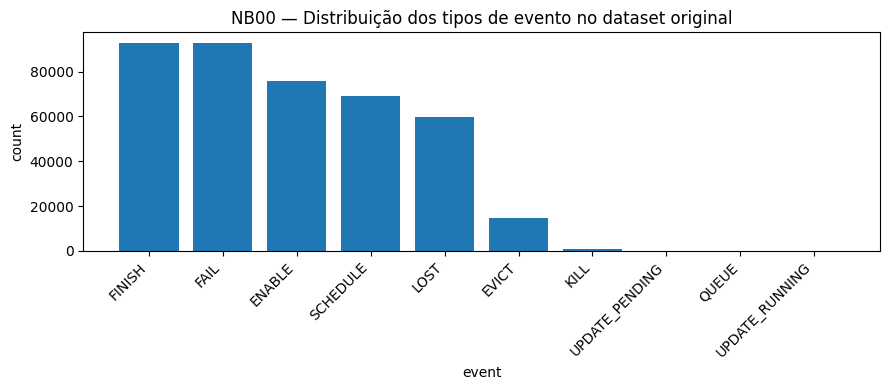


===== Distribuição de failed =====


,failed,count
0,0,313216
1,1,92678


[NB00_AED_CACHE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_01_failed_distribution.png


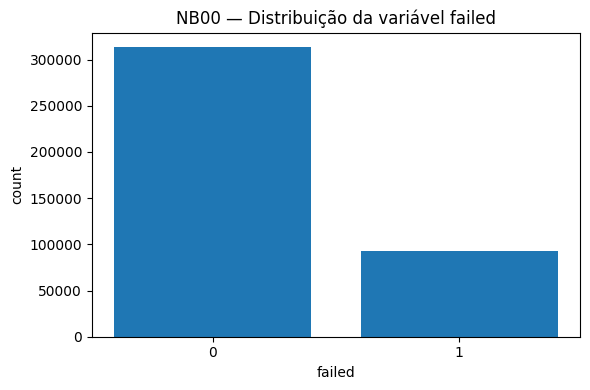


Taxa global de failed: 0.228331

===== Distribuição de scheduling_class =====


,scheduling_class,count
0,0,120414
1,1,105329
2,2,131567
3,3,48584


[NB00_AED_CACHE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_02_scheduling_class_distribution.png


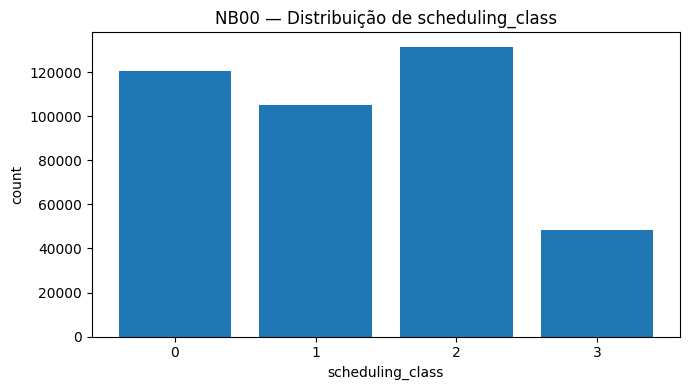


===== Estatísticas de priority =====


,count,mean,std,min,p25,median,p75,max
0,405894,147.913793,116.656633,0.0,103.0,105.0,200.0,450.0


[NB00_AED_CACHE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_03_priority_hist.png


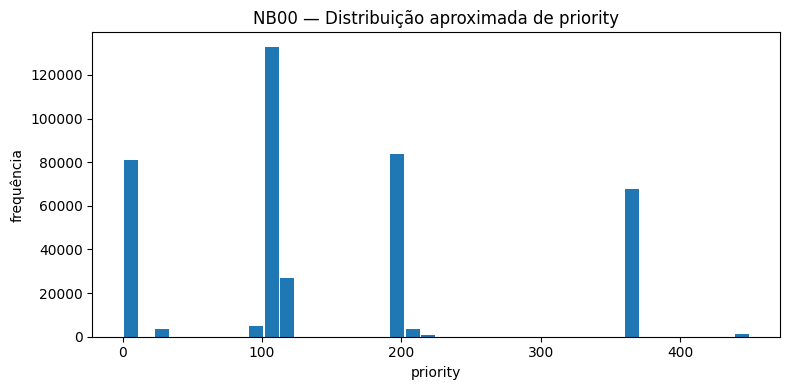


===== Volume por hour =====


,hour,count,failed_count,failed_rate
0,0,56740,37150.0,0.654741
1,1,372,87.0,0.233871
2,2,450,98.0,0.217778
3,3,459,93.0,0.202614
4,4,594,99.0,0.166667
5,5,612,126.0,0.205882
6,6,1016,225.0,0.221457
7,7,896,112.0,0.125000
8,8,868,140.0,0.161290
9,9,947,169.0,0.178458


[NB00_AED_CACHE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_04_hour_distribution.png


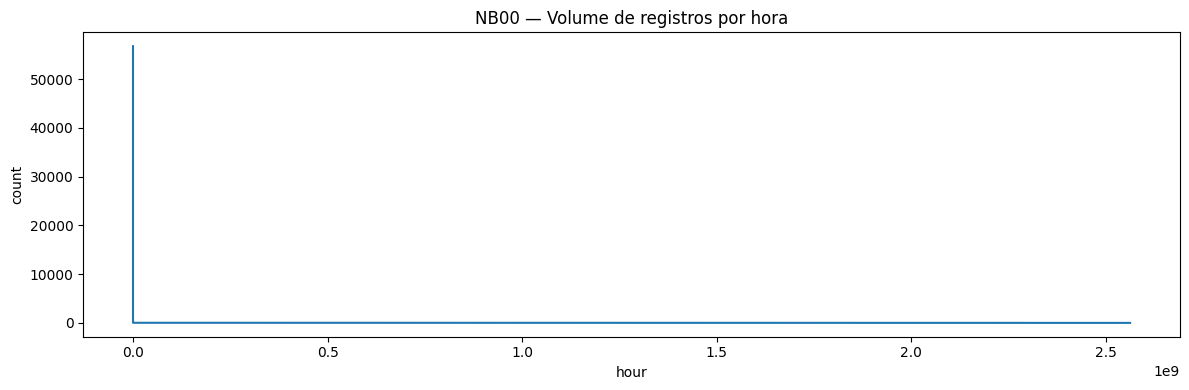

[NB00_AED_CACHE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_05_hour_failed_rate.png


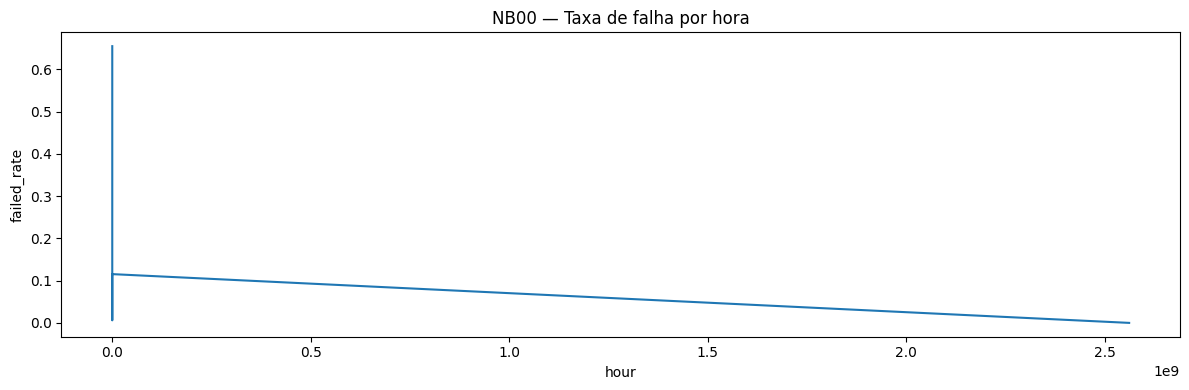


===== Sumário da primeira hora =====


,rows_hour0,failed_sum_hour0,failed_rate_hour0,pct_hour0
0,56740,37150,0.654741,0.13979



===== Distribuição de event em hour == 0 =====


,event,count
0,FAIL,37150
1,ENABLE,18682
2,FINISH,666
3,SCHEDULE,161
4,LOST,78
5,KILL,3


[NB00_AED_CACHE] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_06_hour0_event_distribution.png


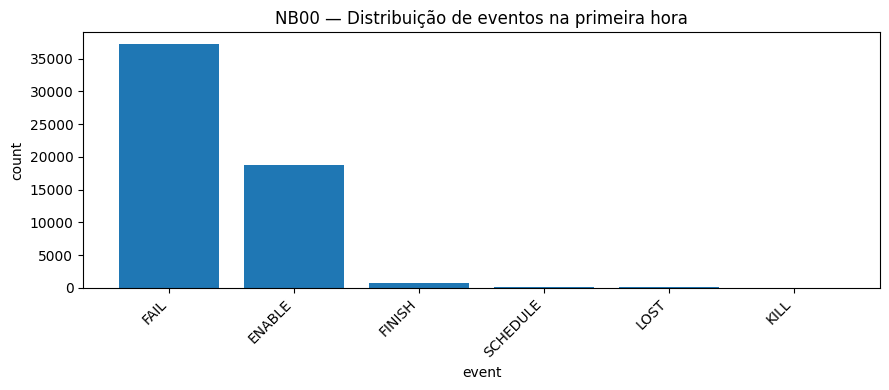

[NB00_AED_CACHE] Criando série exploratória de 5 minutos a partir do cache NB00...


In [ ]:
# ============================================================
# NB00 — Célula 2
# AED memory-safe sobre cache parquet próprio gerado pelo NB00
# NÃO carrega o parquet inteiro em pandas
# ============================================================

from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import duckdb
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb"], check=True)
    import duckdb

# -----------------------------
# 0) Caminhos e parâmetros
# -----------------------------
REPORTS_PATH = Path("/content/drive/MyDrive/Mestrado/04-reports")
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

RAW_FILE = Path("/content/drive/MyDrive/Mestrado/02-datasets/01-raw/borg_traces_data.csv")
AED_CACHE_FILE = REPORTS_PATH / "00_aed_source_cache.parquet"

FIG_DIR = REPORTS_PATH / "figures_nb00_aed"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_FILE = REPORTS_PATH / "00_aed_summary.json"
EXPLORATORY_SERIES_FILE = REPORTS_PATH / "00_aed_exploratory_5min_series.parquet"

WINDOW_MINUTES = 5
WINDOW_US = WINDOW_MINUTES * 60 * 1_000_000
HOUR_US = 60 * 60 * 1_000_000

assert AED_CACHE_FILE.exists(), f"Cache do NB00 não encontrado: {AED_CACHE_FILE}"

print("AED_CACHE_FILE =", AED_CACHE_FILE)
print("REPORTS_PATH =", REPORTS_PATH)
print("FIG_DIR =", FIG_DIR)


def log(msg: str) -> None:
    print(f"[NB00_AED_CACHE] {msg}")


def save_current_fig(filename: str) -> str:
    out = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(out, dpi=150, bbox_inches="tight")
    log(f"Figura salva: {out}")
    plt.show()
    plt.close()
    return str(out)


def sql_path(path: Path) -> str:
    return str(path).replace("'", "''")


def make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if obj is None:
        return None
    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass
    return obj


# -----------------------------
# 1) Conexão DuckDB e view sobre o parquet
# -----------------------------
con = duckdb.connect(database=":memory:")

cache_path_sql = sql_path(AED_CACHE_FILE)
series_path_sql = sql_path(EXPLORATORY_SERIES_FILE)

con.execute(f"""
CREATE OR REPLACE VIEW cache AS
SELECT *
FROM read_parquet('{cache_path_sql}');
""")

schema_df = con.execute("DESCRIBE cache").df()
cache_columns = schema_df["column_name"].tolist()

print("\n===== Colunas no cache NB00 =====")
print(cache_columns)

required_cols = {"time", "event", "failed"}
missing = required_cols - set(cache_columns)
assert not missing, f"Colunas obrigatórias ausentes no cache: {missing}"

has_priority = "priority" in cache_columns
has_scheduling = "scheduling_class" in cache_columns


# -----------------------------
# 2) Sumário estrutural básico
# -----------------------------
basic_info = con.execute("""
SELECT
    COUNT(*) AS rows,
    MIN(time) AS time_min,
    MAX(time) AS time_max
FROM cache;
""").df().iloc[0].to_dict()

rows_total = int(basic_info["rows"])
time_min = int(basic_info["time_min"])
time_max = int(basic_info["time_max"])

basic_summary = {
    "primary_input_file": str(RAW_FILE),
    "cache_file_generated_by_nb00": str(AED_CACHE_FILE),
    "uses_downstream_artifacts": False,
    "rows": rows_total,
    "cols": int(len(cache_columns)),
    "columns": cache_columns,
    "time_min": time_min,
    "time_max": time_max,
    "t_rel_us_min": 0,
    "t_rel_us_max": int(time_max - time_min),
    "hour_min": 0,
    "hour_max": int(np.floor((time_max - time_min) / HOUR_US)),
    "bucket_min": 0,
    "bucket_max": int(np.floor((time_max - time_min) / WINDOW_US)),
    "window_minutes_exploratory": int(WINDOW_MINUTES),
}

print("\n===== Sumário estrutural básico =====")
display(pd.DataFrame([basic_summary]))

sample_df = con.execute("""
SELECT *
FROM cache
LIMIT 5;
""").df()

print("\n===== Amostra do cache =====")
display(sample_df)


# -----------------------------
# 3) Missingness
# -----------------------------
missing_rows = []

for col in cache_columns:
    query = f"""
    SELECT
        COUNT(*) AS total,
        SUM(CASE WHEN "{col}" IS NULL THEN 1 ELSE 0 END) AS missing_count
    FROM cache;
    """
    r = con.execute(query).df().iloc[0].to_dict()
    total = int(r["total"])
    missing_count = int(r["missing_count"] or 0)

    missing_rows.append({
        "column": col,
        "missing_count": missing_count,
        "missing_rate": float(missing_count / total) if total > 0 else None,
    })

missingness = pd.DataFrame(missing_rows).sort_values("missing_rate", ascending=False)

print("\n===== Missingness =====")
display(missingness)


# -----------------------------
# 4) Distribuição de eventos
# -----------------------------
event_counts = con.execute("""
SELECT
    event,
    COUNT(*) AS count
FROM cache
GROUP BY event
ORDER BY count DESC;
""").df()

print("\n===== Distribuição de event =====")
display(event_counts)

plt.figure(figsize=(9, 4))
plt.bar(event_counts["event"].head(15).astype(str), event_counts["count"].head(15))
plt.xticks(rotation=45, ha="right")
plt.xlabel("event")
plt.ylabel("count")
plt.title("NB00 — Distribuição dos tipos de evento no dataset original")
fig_event_distribution = save_current_fig("fig_00_event_distribution.png")


# -----------------------------
# 5) Distribuição de failed
# -----------------------------
failed_counts = con.execute("""
SELECT
    failed,
    COUNT(*) AS count
FROM cache
GROUP BY failed
ORDER BY failed;
""").df()

print("\n===== Distribuição de failed =====")
display(failed_counts)

plt.figure(figsize=(6, 4))
plt.bar(failed_counts["failed"].astype(str), failed_counts["count"])
plt.xlabel("failed")
plt.ylabel("count")
plt.title("NB00 — Distribuição da variável failed")
fig_failed_distribution = save_current_fig("fig_01_failed_distribution.png")

failed_rate_global = con.execute("""
SELECT AVG(CAST(failed AS DOUBLE)) AS failed_rate_global
FROM cache;
""").df().iloc[0]["failed_rate_global"]

failed_rate_global = float(failed_rate_global)
print(f"\nTaxa global de failed: {failed_rate_global:.6f}")


# -----------------------------
# 6) scheduling_class e priority
# -----------------------------
operational_summaries = {}
fig_scheduling_class = None
fig_priority_hist = None

if has_scheduling:
    sched_counts = con.execute("""
    SELECT
        scheduling_class,
        COUNT(*) AS count
    FROM cache
    GROUP BY scheduling_class
    ORDER BY scheduling_class;
    """).df()

    print("\n===== Distribuição de scheduling_class =====")
    display(sched_counts)

    plt.figure(figsize=(7, 4))
    plt.bar(sched_counts["scheduling_class"].astype(str), sched_counts["count"])
    plt.xlabel("scheduling_class")
    plt.ylabel("count")
    plt.title("NB00 — Distribuição de scheduling_class")
    fig_scheduling_class = save_current_fig("fig_02_scheduling_class_distribution.png")

    operational_summaries["scheduling_class_distribution"] = {
        str(k): int(v)
        for k, v in zip(sched_counts["scheduling_class"], sched_counts["count"])
    }

if has_priority:
    priority_desc = con.execute("""
    SELECT
        COUNT(priority) AS count,
        AVG(priority) AS mean,
        STDDEV_SAMP(priority) AS std,
        MIN(priority) AS min,
        QUANTILE_CONT(priority, 0.25) AS p25,
        MEDIAN(priority) AS median,
        QUANTILE_CONT(priority, 0.75) AS p75,
        MAX(priority) AS max
    FROM cache
    WHERE priority IS NOT NULL;
    """).df().iloc[0].to_dict()

    priority_desc = {
        k: (None if pd.isna(v) else float(v) if k != "count" else int(v))
        for k, v in priority_desc.items()
    }

    print("\n===== Estatísticas de priority =====")
    display(pd.DataFrame([priority_desc]))

    priority_min = priority_desc["min"]
    priority_max = priority_desc["max"]

    if priority_min is not None and priority_max is not None and priority_max > priority_min:
        priority_hist = con.execute(f"""
        WITH b AS (
            SELECT
                LEAST(
                    39,
                    GREATEST(
                        0,
                        CAST(FLOOR((priority - {priority_min}) / ({priority_max} - {priority_min}) * 40) AS INTEGER)
                    )
                ) AS bin
            FROM cache
            WHERE priority IS NOT NULL
        )
        SELECT
            bin,
            COUNT(*) AS count
        FROM b
        GROUP BY bin
        ORDER BY bin;
        """).df()

        priority_hist["bin_left"] = priority_min + (priority_hist["bin"] / 40.0) * (priority_max - priority_min)
        priority_hist["bin_right"] = priority_min + ((priority_hist["bin"] + 1) / 40.0) * (priority_max - priority_min)
        priority_hist["bin_mid"] = (priority_hist["bin_left"] + priority_hist["bin_right"]) / 2.0

        plt.figure(figsize=(8, 4))
        plt.bar(priority_hist["bin_mid"], priority_hist["count"], width=(priority_max - priority_min) / 45.0)
        plt.xlabel("priority")
        plt.ylabel("frequência")
        plt.title("NB00 — Distribuição aproximada de priority")
        fig_priority_hist = save_current_fig("fig_03_priority_hist.png")

    operational_summaries["priority"] = priority_desc


# -----------------------------
# 7) Cobertura temporal por hora
# -----------------------------
hourly_summary = con.execute(f"""
WITH base AS (
    SELECT
        CAST(FLOOR((time - {time_min}) / {HOUR_US}) AS BIGINT) AS hour,
        failed
    FROM cache
)
SELECT
    hour,
    COUNT(*) AS count,
    SUM(failed) AS failed_count,
    AVG(CAST(failed AS DOUBLE)) AS failed_rate
FROM base
GROUP BY hour
ORDER BY hour;
""").df()

print("\n===== Volume por hour =====")
display(hourly_summary.head(24))

plt.figure(figsize=(12, 4))
plt.plot(hourly_summary["hour"], hourly_summary["count"])
plt.xlabel("hour")
plt.ylabel("count")
plt.title("NB00 — Volume de registros por hora")
fig_hour_distribution = save_current_fig("fig_04_hour_distribution.png")

plt.figure(figsize=(12, 4))
plt.plot(hourly_summary["hour"], hourly_summary["failed_rate"])
plt.xlabel("hour")
plt.ylabel("failed_rate")
plt.title("NB00 — Taxa de falha por hora")
fig_hour_failed_rate = save_current_fig("fig_05_hour_failed_rate.png")


# -----------------------------
# 8) Primeira hora
# -----------------------------
hour0_summary = con.execute(f"""
WITH base AS (
    SELECT
        CAST(FLOOR((time - {time_min}) / {HOUR_US}) AS BIGINT) AS hour,
        failed
    FROM cache
)
SELECT
    COUNT(*) AS rows_hour0,
    SUM(failed) AS failed_sum_hour0,
    AVG(CAST(failed AS DOUBLE)) AS failed_rate_hour0
FROM base
WHERE hour = 0;
""").df().iloc[0].to_dict()

hour0_summary["rows_hour0"] = int(hour0_summary["rows_hour0"])
hour0_summary["failed_sum_hour0"] = int(hour0_summary["failed_sum_hour0"])
hour0_summary["failed_rate_hour0"] = float(hour0_summary["failed_rate_hour0"])
hour0_summary["pct_hour0"] = float(hour0_summary["rows_hour0"] / rows_total)

print("\n===== Sumário da primeira hora =====")
display(pd.DataFrame([hour0_summary]))

hour0_event_counts = con.execute(f"""
WITH base AS (
    SELECT
        CAST(FLOOR((time - {time_min}) / {HOUR_US}) AS BIGINT) AS hour,
        event
    FROM cache
)
SELECT
    event,
    COUNT(*) AS count
FROM base
WHERE hour = 0
GROUP BY event
ORDER BY count DESC;
""").df()

fig_hour0_event_distribution = None

if len(hour0_event_counts) > 0:
    print("\n===== Distribuição de event em hour == 0 =====")
    display(hour0_event_counts)

    plt.figure(figsize=(9, 4))
    plt.bar(hour0_event_counts["event"].head(15).astype(str), hour0_event_counts["count"].head(15))
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("event")
    plt.ylabel("count")
    plt.title("NB00 — Distribuição de eventos na primeira hora")
    fig_hour0_event_distribution = save_current_fig("fig_06_hour0_event_distribution.png")


# -----------------------------
# 9) Criação da série exploratória de 5 minutos via DuckDB
# -----------------------------
log("Criando série exploratória de 5 minutos a partir do cache NB00...")

if has_priority:
    mean_priority_expr = "AVG(priority) AS mean_priority"
else:
    mean_priority_expr = "NULL::DOUBLE AS mean_priority"

series_agg = con.execute(f"""
    SELECT
        CAST(FLOOR((time - {time_min}) / {WINDOW_US}) AS BIGINT) AS bucket_id,
        COUNT(*) AS n_events,
        SUM(failed) AS n_failed,
        {mean_priority_expr}
    FROM cache
    GROUP BY bucket_id
    ORDER BY bucket_id;
""").df()

max_bucket = int(basic_summary["bucket_max"])

full_buckets = pd.DataFrame({
    "bucket_id": np.arange(0, max_bucket + 1, dtype=np.int64)
})

series_exploratory = full_buckets.merge(
    series_agg,
    on="bucket_id",
    how="left"
)

series_exploratory["bucket_start_us"] = series_exploratory["bucket_id"] * WINDOW_US

series_exploratory["n_events"] = (
    series_exploratory["n_events"]
    .fillna(0)
    .astype(int)
)

series_exploratory["n_failed"] = (
    series_exploratory["n_failed"]
    .fillna(0)
    .astype(int)
)

if "mean_priority" in series_exploratory.columns:
    series_exploratory["mean_priority"] = series_exploratory["mean_priority"].astype(float)

series_exploratory["is_empty_window"] = (
    series_exploratory["n_events"] == 0
).astype(int)

series_exploratory["fail_rate"] = np.where(
    series_exploratory["n_events"] > 0,
    series_exploratory["n_failed"] / series_exploratory["n_events"],
    0.0,
)

# Reordena colunas principais
ordered_cols = [
    "bucket_id",
    "bucket_start_us",
    "n_events",
    "n_failed",
]

if "mean_priority" in series_exploratory.columns:
    ordered_cols.append("mean_priority")

ordered_cols += [
    "is_empty_window",
    "fail_rate",
]

series_exploratory = series_exploratory[ordered_cols]

series_exploratory.to_parquet(EXPLORATORY_SERIES_FILE, index=False)

print("\nSérie exploratória salva em:")
print(EXPLORATORY_SERIES_FILE)

print("\n===== Série exploratória de 5 minutos =====")
print("shape:", series_exploratory.shape)
display(series_exploratory.head())

log("Série exploratória criada com sucesso.")

# -----------------------------
# 10) Sumário e figuras da série exploratória
# -----------------------------
series_summary = {
    "rows": int(len(series_exploratory)),
    "window_minutes": int(WINDOW_MINUTES),
    "empty_windows": int(series_exploratory["is_empty_window"].sum()),
    "empty_windows_rate": float(series_exploratory["is_empty_window"].mean()),
    "n_events_sum": int(series_exploratory["n_events"].sum()),
    "n_failed_sum": int(series_exploratory["n_failed"].sum()),
    "fail_rate_mean": float(series_exploratory["fail_rate"].mean()),
    "fail_rate_std": float(series_exploratory["fail_rate"].std(ddof=0)),
    "fail_rate_min": float(series_exploratory["fail_rate"].min()),
    "fail_rate_p25": float(series_exploratory["fail_rate"].quantile(0.25)),
    "fail_rate_median": float(series_exploratory["fail_rate"].median()),
    "fail_rate_p75": float(series_exploratory["fail_rate"].quantile(0.75)),
    "fail_rate_p95": float(series_exploratory["fail_rate"].quantile(0.95)),
    "fail_rate_max": float(series_exploratory["fail_rate"].max()),
}

mu_fail_rate = series_summary["fail_rate_mean"]
sigma_fail_rate = series_summary["fail_rate_std"]
threshold_mu_2sigma_exploratory = float(mu_fail_rate + 2 * sigma_fail_rate)

series_summary["threshold_mu_2sigma_exploratory"] = threshold_mu_2sigma_exploratory
series_summary["windows_above_threshold_exploratory"] = int(
    (series_exploratory["fail_rate"] >= threshold_mu_2sigma_exploratory).sum()
)

print("\n===== Sumário da série exploratória =====")
display(pd.DataFrame([series_summary]))

plt.figure(figsize=(12, 4))
plt.plot(series_exploratory["bucket_id"], series_exploratory["n_events"])
plt.xlabel("bucket_id")
plt.ylabel("n_events")
plt.title("NB00 — Volume de eventos por janela de 5 minutos")
fig_n_events = save_current_fig("fig_07_n_events_by_bucket.png")

plt.figure(figsize=(12, 4))
plt.plot(series_exploratory["bucket_id"], series_exploratory["n_failed"])
plt.xlabel("bucket_id")
plt.ylabel("n_failed")
plt.title("NB00 — Falhas por janela de 5 minutos")
fig_n_failed = save_current_fig("fig_08_n_failed_by_bucket.png")

plt.figure(figsize=(12, 4))
plt.plot(series_exploratory["bucket_id"], series_exploratory["fail_rate"])
plt.axhline(threshold_mu_2sigma_exploratory, linestyle="--", label="µ + 2σ exploratório")
plt.xlabel("bucket_id")
plt.ylabel("fail_rate")
plt.title("NB00 — Taxa de falha por janela de 5 minutos")
plt.legend(loc="upper right")
fig_fail_rate = save_current_fig("fig_09_fail_rate_by_bucket.png")

plt.figure(figsize=(8, 4))
plt.hist(series_exploratory["fail_rate"], bins=40)
plt.axvline(threshold_mu_2sigma_exploratory, linestyle="--", label="µ + 2σ exploratório")
plt.xlabel("fail_rate")
plt.ylabel("frequência")
plt.title("NB00 — Distribuição da taxa de falha por janela")
plt.legend(loc="upper right")
fig_fail_rate_hist = save_current_fig("fig_10_fail_rate_hist.png")


# -----------------------------
# 11) Sensibilidade exploratória sem primeira hora
# -----------------------------
first_hour_bucket_limit = int(np.floor(HOUR_US / WINDOW_US))

series_no_hour0 = series_exploratory.loc[
    series_exploratory["bucket_id"] >= first_hour_bucket_limit
].copy()

hour0_sensitivity = {}

if len(series_no_hour0) > 0:
    mu_no_h0 = float(series_no_hour0["fail_rate"].mean())
    sigma_no_h0 = float(series_no_hour0["fail_rate"].std(ddof=0))
    thr_no_h0 = float(mu_no_h0 + 2 * sigma_no_h0)

    hour0_sensitivity = {
        "first_hour_bucket_limit": int(first_hour_bucket_limit),
        "rows_all": int(len(series_exploratory)),
        "rows_without_first_hour": int(len(series_no_hour0)),
        "fail_rate_mean_all": float(mu_fail_rate),
        "fail_rate_std_all": float(sigma_fail_rate),
        "threshold_mu_2sigma_all_exploratory": float(threshold_mu_2sigma_exploratory),
        "windows_above_threshold_all_exploratory": int(
            (series_exploratory["fail_rate"] >= threshold_mu_2sigma_exploratory).sum()
        ),
        "fail_rate_mean_without_first_hour": mu_no_h0,
        "fail_rate_std_without_first_hour": sigma_no_h0,
        "threshold_mu_2sigma_without_first_hour_exploratory": thr_no_h0,
        "windows_above_threshold_without_first_hour_exploratory": int(
            (series_no_hour0["fail_rate"] >= thr_no_h0).sum()
        ),
    }

    print("\n===== Sensibilidade exploratória: com e sem primeira hora =====")
    display(pd.DataFrame([hour0_sensitivity]))


# -----------------------------
# 12) Achados e summary
# -----------------------------
findings = [
    f"O dataset original contém {basic_summary['rows']} registros no cache técnico gerado pelo NB00.",
    f"A taxa global de registros marcados como failed foi {failed_rate_global:.4f}.",
    f"A primeira hora contém {hour0_summary['rows_hour0']} registros, correspondendo a {hour0_summary['pct_hour0']:.4f} do total.",
    f"A agregação exploratória em janelas de {WINDOW_MINUTES} minutos gerou {series_summary['rows']} janelas.",
    f"A taxa de falha média por janela foi {series_summary['fail_rate_mean']:.4f}, com percentil 95 igual a {series_summary['fail_rate_p95']:.4f}.",
    "O limiar µ+2σ calculado no NB00 é apenas exploratório e não substitui o limiar oficial calculado nos notebooks posteriores.",
]

print("\n===== Achados exploratórios principais =====")
for item in findings:
    print("-", item)

summary = {
    "notebook": "NB00",
    "purpose": "initial_exploratory_data_analysis_from_original_kaggle_csv_using_nb00_cache_memory_safe",
    "input_policy": {
        "primary_input_file": str(RAW_FILE),
        "cache_file_generated_by_nb00": str(AED_CACHE_FILE),
        "uses_downstream_artifacts": False,
        "note": (
            "The NB00 uses only the original Kaggle CSV as primary input. "
            "A temporary parquet cache is generated by NB00 itself to avoid RAM exhaustion in Colab. "
            "The AED is computed with DuckDB aggregations over the cache, without loading the full dataset into pandas. "
            "No downstream notebook artifact is used."
        ),
    },
    "basic_summary": basic_summary,
    "missingness": missingness.to_dict("records"),
    "event_distribution": {str(k): int(v) for k, v in zip(event_counts["event"], event_counts["count"])},
    "failed_distribution": {str(k): int(v) for k, v in zip(failed_counts["failed"], failed_counts["count"])},
    "failed_rate_global": failed_rate_global,
    "operational_summaries": operational_summaries,
    "hour0_summary": hour0_summary,
    "hourly_summary_head": hourly_summary.head(24).to_dict("records"),
    "series_exploratory": series_summary,
    "hour0_sensitivity_exploratory": hour0_sensitivity,
    "figures": {
        "event_distribution": fig_event_distribution,
        "failed_distribution": fig_failed_distribution,
        "scheduling_class_distribution": fig_scheduling_class,
        "priority_hist": fig_priority_hist,
        "hour_distribution": fig_hour_distribution,
        "hour_failed_rate": fig_hour_failed_rate,
        "hour0_event_distribution": fig_hour0_event_distribution,
        "n_events_by_bucket": fig_n_events,
        "n_failed_by_bucket": fig_n_failed,
        "fail_rate_by_bucket": fig_fail_rate,
        "fail_rate_hist": fig_fail_rate_hist,
    },
    "outputs": {
        "summary_file": str(SUMMARY_FILE),
        "exploratory_series_file": str(EXPLORATORY_SERIES_FILE),
        "figures_dir": str(FIG_DIR),
    },
    "findings": findings,
}

SUMMARY_FILE.write_text(
    json.dumps(make_json_safe(summary), indent=2, ensure_ascii=False),
    encoding="utf-8",
)

con.close()

log(f"Resumo salvo: {SUMMARY_FILE}")
log(f"Série exploratória salva: {EXPLORATORY_SERIES_FILE}")
log("NB00 executado com sucesso.")

print("\n=== RESUMO FINAL — NB00 ===")
print(f"Entrada primária: CSV bruto do Kaggle")
print(f"Cache próprio do NB00: {AED_CACHE_FILE}")
print(f"Linhas analisadas: {basic_summary['rows']}")
print(f"Figuras: {FIG_DIR}")
print(f"Summary: {SUMMARY_FILE}")
print(f"Série exploratória: {EXPLORATORY_SERIES_FILE}")
print("\nImportante: este notebook não leu artefatos de notebooks posteriores.")